In [ ]:
# %pip install -r requirements.txt

## Imports


In [1]:
import numpy as np  # For working with large arrays and matrices
import matplotlib.pyplot as plt  # For plotting and visualization
import torch  # For deep learning and tensor computations
import monai  # For medical imaging AI tools and utilities
import sklearn  # For machine learning algorithms and utilities
import scipy  # For scientific computing and image processing
import nibabel as nib  # For loading and working with neuro-imaging data
import os  # For interacting with the operating system
import shutil  # For high-level file operations
import time  # For measuring execution time
import joblib  # For parallel processing
import itertools  # For efficient looping and combinatorial operations
import tqdm  # For progress bars
import json  # For working with JSON data
import random  # For random number generation and shuffling

## Task 1: Understand the Dataset


# Dataset <a name="dataset"></a>

The training dataset provided for the BraTS21 challenge consists of 1,251 brain mpMRI scans along with segmentation annotations of tumorous regions. The 3D volumes were skull-stripped and resampled to 1 mm isotropic resolution, with dimensions of (240, 240, 155) voxels. For each example, four modalities were given: Fluid Attenuated Inversion Recovery (FLAIR), native (T1), post-contrast T1-weighted (T1Gd), and T2-weighted (T2). See image below with each modality. Annotations consist of four classes: 1 for necrotic tumor core (NCR), 2 for peritumoral edematous tissue (ED), 4 for enhancing tumor (ET), and 0 for background (voxels that are not part of the tumor).


In the **BraTS 2021 (Brain Tumor Segmentation)** dataset, the training data is organized into subject-specific folders. Each folder typically contains **5 NIfTI files** (`.nii.gz`), representing four different MRI modalities and one ground truth segmentation mask.

All images have been pre-processed: they are co-registered to the same anatomical template, resampled to a uniform isotropic resolution ($1 \text{mm}^3$), and skull-stripped.

---

### 1. `_t1.nii.gz` (Native T1-weighted)

The native T1-weighted scan is the "baseline" structural image. It is excellent for viewing normal brain anatomy.

- **Visual appearance:** Cerebrospinal fluid (CSF) appears dark, while white matter appears lighter than gray matter.
- **Purpose:** It serves as the primary structural reference for the other scans.

### 2. `_t1ce.nii.gz` (Post-contrast T1-weighted)

Also known as **T1Gd** (Gadolinium-enhanced), this is a T1-weighted scan taken after a contrast agent (Gadolinium) is injected into the patient.

- **Visual appearance:** Blood vessels and areas where the blood-brain barrier is compromised—like the "active" part of a tumor—appear very bright (hyperintense).
- **Purpose:** It is the primary modality used to identify the **Enhancing Tumor (ET)** region.

### 3. `_t2.nii.gz` (T2-weighted)

T2-weighted scans are highly sensitive to water and fluid.

- **Visual appearance:** Fluid-filled areas like CSF and many types of lesions (like the tumor core) appear very bright.
- **Purpose:** Helps in identifying the overall **Tumor Core (TC)** and distinguishes liquid-filled areas from solid tissue.

### 4. `_flair.nii.gz` (Fluid Attenuated Inversion Recovery)

FLAIR is a special T2-weighted sequence where the signal from free-flowing water (like CSF) is suppressed or "nullified."

- **Visual appearance:** The brain looks similar to a T2 scan, but the dark CSF makes the bright abnormalities (like edema) stand out much more clearly.
- **Purpose:** It is critical for defining the **Whole Tumor (WT)**, especially the peritumoral edema (swelling) that surrounds the core.

### 5. `_seg.nii.gz` (Ground Truth Segmentation)

This is the manually annotated label file created by expert neuroradiologists. It contains integer values (labels) that categorize each voxel into a specific tumor sub-region:

| Label | Sub-region  | Description                                        |
| :---- | :---------- | :------------------------------------------------- |
| **0** | Background  | Healthy brain tissue or non-brain space.           |
| **1** | **NCR/NET** | Necrotic (dead) and Non-Enhancing tumor core.      |
| **2** | **ED**      | Peritumoral Edema (swelling around the tumor).     |
| **4** | **ET**      | GD-Enhancing Tumor (the active part of the tumor). |

_(Note: Label 3 is historically unused in the BraTS 2021 challenge format.)_

---

### Summary of Tumor Sub-regions

When evaluating models, these labels are usually grouped into three nested classes:

- **Whole Tumor (WT):** Labels 1 + 2 + 4 (Everything abnormal)
- **Tumor Core (TC):** Labels 1 + 4 (The solid tumor)
- **Enhancing Tumor (ET):** Label 4 only


Image t1 shape: (240, 240, 155)
Image t1ce shape: (240, 240, 155)
Image t2 shape: (240, 240, 155)
Image flair shape: (240, 240, 155)
Label shape: (240, 240, 155)


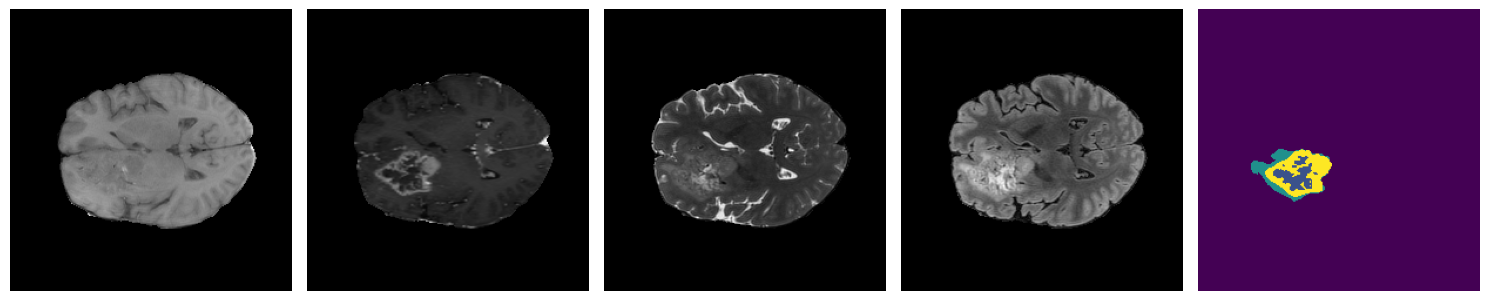

In [2]:
modalities = ["t1", "t1ce", "t2", "flair"]

imgs = [
    nib.load(f".raw/BraTS2021_00000/BraTS2021_00000_{mod}.nii.gz")
    .get_fdata()
    .astype(np.float32)
    for mod in modalities
]
lbl = (
    nib.load(".raw/BraTS2021_00000/BraTS2021_00000_seg.nii.gz")
    .get_fdata()
    .astype(np.uint8)
)

for i, img in enumerate(imgs):
    print(f"Image {modalities[i]} shape: {img.shape}")
print(f"Label shape: {lbl.shape}")

fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(15, 15))
for i, img in enumerate(imgs):
    ax[i].imshow(img[:, :, 75], cmap="gray")
    ax[i].axis("off")
ax[-1].imshow(lbl[:, :, 75], vmin=0, vmax=4)
ax[-1].axis("off")
plt.tight_layout()
plt.show()

## Task 2: Preprocessing & Data Augmentation


### Preprocess MRI scans


In [3]:
raw_data_path = ".raw"
processed_data_path = ".processed"

if not os.path.exists(raw_data_path):
    raise FileNotFoundError(f"Raw data directory '{raw_data_path}' does not exist.")

if not os.path.exists(processed_data_path):
    os.makedirs(processed_data_path)

raw_data_dirs = [
    d
    for d in os.listdir(raw_data_path)
    if os.path.isdir(os.path.join(raw_data_path, d))
]

processed_data_dirs = [
    d
    for d in os.listdir(processed_data_path)
    if os.path.isdir(os.path.join(processed_data_path, d))
]

if len(raw_data_dirs) != len(processed_data_dirs):
    shutil.rmtree(processed_data_path)
    os.makedirs(processed_data_path)

if len(raw_data_dirs) == len(processed_data_dirs):
    print("Total data samples:", len(raw_data_dirs))
    print("All raw data has already been processed.")
    print("Do you want to reprocess the data? (y/n)")
    if input().lower() == "y":
        shutil.rmtree(processed_data_path)
        os.makedirs(processed_data_path)


In [4]:
def run_parallel(func, ids):
    return joblib.Parallel(n_jobs=os.cpu_count())(
        joblib.delayed(func)(id) for id in ids
    )


class StopExecution(Exception):
    def _render_traceback_(self):
        return []

In [5]:
def collect_intensities(ids):

    intensities_dicts = run_parallel(get_intensities, ids)

    intensities = {}
    intensity_min = {}
    intensity_max = {}
    intensity_mean = {}
    intensity_std = {}

    for mod in modalities:
        # Chain the intensity values from all patients for the current modality into a single list.
        intensities[mod] = list(itertools.chain(*[d[mod] for d in intensities_dicts]))
        # Calculate the 0.5th and 99.5th percentiles to determine the minimum and maximum intensity values for normalization,
        # and calculate the mean and standard deviation for further normalization steps.
        intensity_min[mod] = np.percentile(intensities[mod], [0.5, 99.5])[0]
        intensity_max[mod] = np.percentile(intensities[mod], [0.5, 99.5])[1]
        intensity_mean[mod] = np.mean(intensities[mod])
        intensity_std[mod] = np.std(intensities[mod])

    return {
        "min": intensity_min,
        "max": intensity_max,
        "mean": intensity_mean,
        "std": intensity_std,
    }


def get_intensities(id):
    intensity = {}
    # Loop through each modality for the patient and load the corresponding image and label to extract intensity values.
    for mod in modalities:
        image = (
            nib.load(
                os.path.join(
                    raw_data_path,
                    f"BraTS2021_{id}",
                    f"BraTS2021_{id}_{mod}.nii.gz",
                )
            )
            .get_fdata()
            .astype(np.float32)
        )
        label = (
            nib.load(
                os.path.join(
                    raw_data_path,
                    f"BraTS2021_{id}",
                    f"BraTS2021_{id}_seg.nii.gz",
                )
            )
            .get_fdata()
            .astype(np.uint8)
        )
        # Extract brain region
        foreground_area = np.where(label > 0)
        # Store the intensity values of the brain region for the current modality in the intensity dictionary as a list.
        intensity[mod] = image[foreground_area].tolist()
    return intensity

In [6]:
def preprocess_images(ids, intensity_stats):
    run_parallel(process_image, ids, intensity_stats)


def process_image(id, intensity_stats):
    os.makedirs(os.path.join(processed_data_path, f"BraTS2021_{id}"))

    images = {}
    for mod in modalities:
        # Load the image for the current modality and patient
        image = nib.load(
            os.path.join(
                raw_data_path,
                f"BraTS2021_{id}",
                f"BraTS2021_{id}_{mod}.nii.gz",
            )
        )
        images[mod] = image

    img_header = images["t1"].header
    img_affine = images["t1"].affine

    normalized_data = {}
    for mod in modalities:
        image = images[mod].get_fdata().astype(np.float32)
        image = np.clip(image, intensity_stats["min"][mod], intensity_stats["max"][mod])
        image = (image - intensity_stats["mean"][mod]) / intensity_stats["std"][mod]
        normalized_data[mod] = image

    channels_data = np.stack([normalized_data[mod] for mod in modalities], axis=0)
    # ==========================================
    # NEW PADDING LOGIC (Features)
    # Target: (256, 256, 160)
    # Original: (240, 240, 155)
    # Difference: Height=16, Width=16, Depth=5
    # ==========================================
    pad_width = ((0, 0), (0, 16), (0, 16), (0, 5))
    channels_data = np.pad(channels_data, pad_width, mode="constant", constant_values=0)

    channels_img = nib.Nifti1Image(
        channels_data.astype(np.float32), img_affine, header=img_header
    )

    nib.save(
        channels_img,
        os.path.join(
            processed_data_path,
            f"BraTS2021_{id}",
            f"BraTS2021_{id}.nii.gz",
        ),
    )

    # Load the label image for the patient
    label = nib.load(
        os.path.join(
            raw_data_path,
            f"BraTS2021_{id}",
            f"BraTS2021_{id}_seg.nii.gz",
        )
    )
    lbl_header = label.header
    lbl_affine = label.affine
    lbl_data = label.get_fdata().astype(np.uint8)

    # This ensures classes are [0, 1, 2, 3] instead of [0, 1, 2, 4]
    lbl_data[lbl_data == 4] = 3
    lbl_data = np.expand_dims(lbl_data, axis=0).astype(np.uint8)
    lbl_data = np.pad(lbl_data, pad_width, mode="constant", constant_values=0)

    ohc_label = nib.Nifti1Image(
        lbl_data.astype(np.uint8), lbl_affine, header=lbl_header
    )
    nib.save(
        ohc_label,
        os.path.join(
            processed_data_path, f"BraTS2021_{id}", f"BraTS2021_{id}_seg.nii.gz"
        ),
    )

In [8]:
pt_ids = [d.split("_")[-1] for d in raw_data_dirs]
pt_ids.sort()

if len(raw_data_dirs) == len(processed_data_dirs):
    raise StopExecution("Preprocessing skipped. All data is already processed.")


print("Do you want to recalculate the intensity statistics? (y/n)")
if input().lower() != "y":
    print("Using existing intensity statistics.")
    intensity_stats = {
        "min": {"t1": 60.00, "t1ce": 47.00, "t2": 115.00, "flair": 115.00},
        "max": {"t1": 6483.00, "t1ce": 7956.00, "t2": 12371.00, "flair": 13702.00},
        "mean": {"t1": 862.64, "t1ce": 1553.63, "t2": 1901.65, "flair": 1080.03},
        "std": {"t1": 1807.43, "t1ce": 16210.56, "t2": 39182.12, "flair": 4100.89},
    }
else:
    print("Collecting intensity values for normalization...")
    intensity_start = time.time()
    intensity_stats = collect_intensities(pt_ids)
    intensity_end = time.time()
    print(f"Intensities collected in {intensity_end - intensity_start:.2f} seconds.")

print("Intensity statistics:")
print("Min:", intensity_stats["min"])
print("Max:", intensity_stats["max"])
print("Mean:", intensity_stats["mean"])
print("Std:", intensity_stats["std"])


print("Processing raw data...")
preprocessing_start = time.time()
preprocess_images(pt_ids, intensity_stats)
print(f"Processed {len(pt_ids)} images.")
preprocessing_end = time.time()
print(
    f"Image preprocessing completed in {preprocessing_end - preprocessing_start:.2f} seconds."
)

Do you want to recalculate the intensity statistics? (y/n)
Using existing intensity statistics.
Intensity statistics:
Min: {'t1': 60.0, 't1ce': 47.0, 't2': 115.0, 'flair': 115.0}
Max: {'t1': 6483.0, 't1ce': 7956.0, 't2': 12371.0, 'flair': 13702.0}
Mean: {'t1': 862.64, 't1ce': 1553.63, 't2': 1901.65, 'flair': 1080.03}
Std: {'t1': 1807.43, 't1ce': 16210.56, 't2': 39182.12, 'flair': 4100.89}
Processing raw data...


TypeError: run_parallel() takes 2 positional arguments but 3 were given

In [ ]:
# def biased_crop(image, label, crop_size):
#     """1. Biased crop with 0.4 prob to guarantee foreground."""
#     _, d, h, w = image.shape
#     cd, ch, cw = crop_size

#     if np.random.rand() < 0.4 and np.any(label > 0):
#         fg_indices = np.argwhere(label > 0)
#         center_voxel = fg_indices[np.random.choice(len(fg_indices))]

#         _, z, y, x = center_voxel

#         z_start = max(0, min(z - cd // 2, d - cd))
#         y_start = max(0, min(y - ch // 2, h - ch))
#         x_start = max(0, min(x - cw // 2, w - cw))
#     else:
#         z_start = np.random.randint(0, d - cd + 1)
#         y_start = np.random.randint(0, h - ch + 1)
#         x_start = np.random.randint(0, w - cw + 1)

#     cropped_img = image[
#         :, z_start : z_start + cd, y_start : y_start + ch, x_start : x_start + cw
#     ]

#     cropped_lbl = label[
#         :, z_start : z_start + cd, y_start : y_start + ch, x_start : x_start + cw
#     ]

#     return cropped_img, cropped_lbl


def center_crop(image, label, crop_size):
    """Helper for validation consistency."""
    _, d, h, w = image.shape
    cd, ch, cw = crop_size

    z_start = (d - cd) // 2
    y_start = (h - ch) // 2
    x_start = (w - cw) // 2

    cropped_img = image[
        :, z_start : z_start + cd, y_start : y_start + ch, x_start : x_start + cw
    ]

    cropped_lbl = label[
        :, z_start : z_start + cd, y_start : y_start + ch, x_start : x_start + cw
    ]

    return cropped_img, cropped_lbl


def apply_zoom(image, label):
    """2. Zoom (0.15 prob, 1.0 to 1.4)."""
    if np.random.rand() < 0.15:
        zoom_factor = np.random.uniform(1.0, 1.4)
        # Do not zoom the channel dimension
        zoom_tuple = (1.0, zoom_factor, zoom_factor, zoom_factor)

        # Cubic interpolation (order=3) for image, Nearest Neighbor (order=0) for label
        img_size = image.shape[1:]
        image = scipy.ndimage.zoom(image, zoom_tuple, order=3, mode="nearest")

        label = scipy.ndimage.zoom(
            label,
            zoom_tuple,
            order=0,
            mode="nearest",
        )

        # Crop back down to original size after zooming
        image, label = center_crop(image, label, img_size)

    return image, label


def apply_flips(image, label):
    """3. Flips (0.5 prob per axis)."""
    # Axes for D, H, W (skipping Channel at index 0)
    axes = [1, 2, 3]

    for axis in axes:
        if np.random.rand() < 0.5:
            image = np.flip(image, axis=axis)
            lbl_axis = axis
            label = np.flip(label, axis=lbl_axis)

    # Ensure memory continuity after flipping
    return np.ascontiguousarray(image), np.ascontiguousarray(label)


def apply_gaussian_noise(image):
    """4. Gaussian Noise (0.15 prob, stddev 0 to 0.33)."""
    if np.random.rand() < 0.15:
        std = np.random.uniform(0.0, 0.33)
        noise = np.random.normal(0, std, image.shape)
        image = image + noise
    return image.astype(np.float32)


def apply_gaussian_blur(image):
    """5. Gaussian Blur (0.15 prob, sigma 0.5 to 1.5)."""
    if np.random.rand() < 0.15:
        sigma = np.random.uniform(0.5, 1.5)
        # Apply blur to spatial dimensions, not the channel dimension
        image = scipy.ndimage.gaussian_filter(image, sigma=(0, sigma, sigma, sigma))
    return image


def apply_brightness(image):
    """6. Brightness (0.15 prob, factor 0.7 to 1.3)."""
    if np.random.rand() < 0.15:
        factor = np.random.uniform(0.7, 1.3)
        image = image * factor
    return image


def apply_contrast(image):
    """7. Contrast (0.15 prob, factor 0.65 to 1.5)."""
    if np.random.rand() < 0.15:
        factor = np.random.uniform(0.65, 1.5)
        img_min, img_max = image.min(), image.max()
        image = image * factor
        # Clip back to original min/max values
        image = np.clip(image, img_min, img_max)
    return image

In [ ]:
def apply_augmentation(image, label, isTraining=True):
    crop_size = (128, 128, 128)
    if isTraining:
        # # 1. Biased Crop
        # image, label = biased_crop(image, label, crop_size)
        # 2. Zoom
        image, label = apply_zoom(image, label)
        # 3. Flips
        image, label = apply_flips(image, label)
        # 4. Gaussian Noise
        image = apply_gaussian_noise(image)
        # 5. Gaussian Blur
        image = apply_gaussian_blur(image)
        # 6. Brightness
        image = apply_brightness(image)
        # 7. Contrast
        image = apply_contrast(image)
    # else:
    #     # If testing/validating, apply standard center crop to match dimensions
    #     image, label = center_crop(image, label, crop_size)

    return image, label

In [ ]:
class BraTSDataset(torch.utils.data.Dataset):
    def __init__(self, data_path, pt_ids, isTraining=True):
        self.data_path = data_path
        self.pt_ids = pt_ids
        self.isTraining = isTraining

    def __len__(self):
        # PyTorch needs to know how many total patients there are
        return len(self.pt_ids)

    def __getitem__(self, idx):
        pt_id = self.pt_ids[idx]

        img_path = os.path.join(
            self.data_path, f"BraTS2021_{pt_id}", f"BraTS2021_{pt_id}.nii.gz"
        )
        lbl_path = os.path.join(
            self.data_path, f"BraTS2021_{pt_id}", f"BraTS2021_{pt_id}_seg.nii.gz"
        )

        image = nib.load(img_path).get_fdata().astype(np.float32)
        label = nib.load(lbl_path).get_fdata().astype(np.uint8)

        image, label = apply_augmentation(image, label, self.isTraining)

        return torch.from_numpy(image), torch.from_numpy(label)

In [ ]:
train_ids, test_ids = sklearn.model_selection.train_test_split(
    pt_ids, test_size=0.2, random_state=123
)

In [ ]:
training_dataset = BraTSDataset(processed_data_path, train_ids, isTraining=True)
train_loader = torch.utils.data.DataLoader(training_dataset, batch_size=5, shuffle=True)

val_dataset = BraTSDataset(processed_data_path, test_ids, isTraining=False)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=5, shuffle=False)

# kf = sklearn.model_selection.KFold(n_splits=5, shuffle=True, random_state=123)
# folds = list(kf.split(pt_ids))
# train_indices, val_indices = folds[0] # Select Fold 0

## Task 3


We have made some modifications to the U-Net architecture for the BraTS challenge with respect to the original nnU-Net template. In particular, the U-Net template in the nnU-Net has the encoder depth of 6, and the convolution channels at each encoder level are: 32, 64, 128, 256, 320, 320. Based on the experiments we run, increasing the depth of the encoder to 7, modifying the number of channels to: 64, 96, 128, 192, 256, 384, 512, and using deep supervision improves the final score.

For deep supervision, we used two additional output heads at the decoder levels with feature map sizes (64, 64, 64) and (32, 32, 32). To match the shape of the additional predictions with the label shape of (128, 128, 128) we downsampled the label using the nearest neighbor interpolation to the (64, 64, 64) and (32, 32, 32) shapes, so that loss can be computed for additional outputs.


In [ ]:
from IPython.display import Image

Image(filename=".images/output.jpeg")

In [ ]:
class ConvBlock(torch.nn.Module):
    """
    Standard nnU-Net Block:
    Conv3d -> InstanceNorm3d -> LeakyReLU -> Conv3d -> InstanceNorm3d -> LeakyReLU
    """

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = torch.nn.Conv3d(
            in_channels, out_channels, kernel_size=3, padding=1, bias=False
        )
        self.norm1 = torch.nn.InstanceNorm3d(out_channels)
        self.relu1 = torch.nn.LeakyReLU(inplace=True)

        self.conv2 = torch.nn.Conv3d(
            out_channels, out_channels, kernel_size=3, padding=1, bias=False
        )
        self.norm2 = torch.nn.InstanceNorm3d(out_channels)
        self.relu2 = torch.nn.LeakyReLU(inplace=True)

    def forward(self, x):
        return self.relu2(self.norm2(self.conv2(self.relu1(self.norm1(self.conv1(x))))))


class DownConvBlock(torch.nn.Module):
    """
    Downsampling Block using Strided Convolution
    """

    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Stride 2 replaces MaxPool
        self.conv1 = torch.nn.Conv3d(
            in_channels, out_channels, kernel_size=3, stride=2, padding=1, bias=False
        )
        self.norm1 = torch.nn.InstanceNorm3d(out_channels)
        self.relu1 = torch.nn.LeakyReLU(inplace=True)

        self.conv2 = torch.nn.Conv3d(
            out_channels, out_channels, kernel_size=3, padding=1, bias=False
        )
        self.norm2 = torch.nn.InstanceNorm3d(out_channels)
        self.relu2 = torch.nn.LeakyReLU(inplace=True)

    def forward(self, x):
        return self.relu2(self.norm2(self.conv2(self.relu1(self.norm1(self.conv1(x))))))


class nnUNet(torch.nn.Module):
    def __init__(self, in_channels=4, out_channels=4):
        super().__init__()

        # --- ENCODER (Depth 6) ---
        # Channels: 32, 64, 128, 256, 320, 320
        self.enc1 = ConvBlock(in_channels, 32)
        self.enc2 = DownConvBlock(32, 64)
        self.enc3 = DownConvBlock(64, 128)
        self.enc4 = DownConvBlock(128, 256)
        self.enc5 = DownConvBlock(256, 320)

        # Level 6 acts as the Bottleneck
        self.bottleneck = DownConvBlock(320, 320)

        # --- DECODER (Mirroring Encoder) ---
        # Up-conv + Skip Connection + Double Conv

        # From bottleneck to enc5 level
        self.up5 = torch.nn.ConvTranspose3d(320, 320, kernel_size=2, stride=2)
        self.dec5 = ConvBlock(320 + 320, 320)  # 320 (up) + 320 (skip)

        # From level 5 to enc4 level
        self.up4 = torch.nn.ConvTranspose3d(320, 256, kernel_size=2, stride=2)
        self.dec4 = ConvBlock(256 + 256, 256)

        # From level 4 to enc3 level
        self.up3 = torch.nn.ConvTranspose3d(256, 128, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(128 + 128, 128)

        # From level 3 to enc2 level
        self.up2 = torch.nn.ConvTranspose3d(128, 64, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(64 + 64, 64)

        # From level 2 to enc1 level
        self.up1 = torch.nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(32 + 32, 32)

        # Final Segmentation Head
        self.final_conv = torch.nn.Conv3d(32, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)

        # Bottleneck (Level 6)
        b = self.bottleneck(e5)

        # Decoder with Skip Connections
        d5 = self.dec5(torch.cat([self.up5(b), e5], dim=1))
        d4 = self.dec4(torch.cat([self.up4(d5), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.final_conv(d1)

## Training


In [ ]:
def train_modelasa(model, train_loader, val_loader, num_epochs, lr):
    # Move model to GPU/CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on device: {device}")
    device = "cpu"
    model = model.to(device)

    # Initialize Optimizer and Loss
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = monai.losses.DiceCELoss(to_onehot_y=True, softmax=True, batch=True)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

    print(f"Starting training on device: {device}")

    # -----------------------------------------
    # Early Stopping & Saving Setup
    # -----------------------------------------
    start_epoch = 0
    best_val_loss = float("inf")  # Start with an infinitely high loss
    patience = 5
    epochs_no_improve = 0

    # -----------------------------------------
    # RESUME FROM CHECKPOINT LOGIC
    # -----------------------------------------
    resume_checkpoint = "model.pth"
    if resume_checkpoint is not None and os.path.isfile(resume_checkpoint):
        print(f"=> Loading checkpoint '{resume_checkpoint}'...")
        checkpoint = torch.load(resume_checkpoint, map_location=device)

        # Restore all states
        start_epoch = checkpoint["epoch"] + 1  # Start from the next epoch
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        best_val_loss = checkpoint["best_val_loss"]
        epochs_no_improve = checkpoint["epochs_no_improve"]

        print(
            f"=> Resuming training from epoch {start_epoch + 1} (Best Val Loss so far: {best_val_loss:.4f})"
        )
    elif resume_checkpoint is not None:
        print(
            f"=> Warning: Checkpoint '{resume_checkpoint}' not found. Starting from scratch."
        )

    print(f"Starting training for {num_epochs} epochs...")

    for epoch in range(start_epoch, num_epochs):
        # =========================================
        # 1. TRAINING PHASE
        # =========================================
        model.train()  # Set model to training mode
        train_loss = 0.0

        # Initialize the progress bar for the training loader
        train_pbar = tqdm.tqdm(
            train_loader, desc=f"Epoch {epoch + 1}/{num_epochs} [Train]", leave=False
        )

        for images, labels in train_pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()  # Clear old gradients

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Track loss and update progress bar text
            train_loss += loss.item()
            train_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_train_loss = train_loss / len(train_loader)

        # =========================================
        # 2. VALIDATION PHASE
        # =========================================
        model.eval()  # Set model to evaluation mode (turns off dropout/batchnorm updates)
        val_loss = 0.0

        # Initialize the progress bar for the validation loader
        val_pbar = tqdm.tqdm(
            val_loader, desc=f"Epoch {epoch + 1}/{num_epochs} [Val]", leave=False
        )

        with torch.no_grad():  # Disable gradient calculation to save memory and compute
            for images, labels in val_pbar:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_val_loss = val_loss / len(val_loader)

        # Step the learning rate scheduler at the end of the epoch
        scheduler.step()

        # Print Epoch Summary
        print(
            f"Epoch {epoch + 1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}"
        )

        # =========================================
        # 3. CHECKPOINTING & EARLY STOPPING
        # =========================================

        # A. Save the BEST model (for final testing/inference)
        if avg_val_loss < best_val_loss:
            print(
                f"  -> Validation loss improved from {best_val_loss:.4f} to {avg_val_loss:.4f}. Saving best model..."
            )
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), "best_nnunet_model.pth")
        else:
            epochs_no_improve += 1
            print(
                f"  -> No improvement in validation loss for {epochs_no_improve} epoch(s)."
            )

        # B. Save the LATEST state (for resuming training if interrupted)
        checkpoint_state = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_loss": best_val_loss,
            "epochs_no_improve": epochs_no_improve,
        }
        torch.save(checkpoint_state, "model.pth")

        # C. Check Early Stopping
        if epochs_no_improve >= patience:
            print(
                f"\nEarly stopping triggered! Validation loss hasn't improved in {patience} epochs."
            )
            break

    print(
        "Training complete. You can now load 'best_nnunet_model.pth' for testing/inference."
    )
    return model


In [ ]:
def compute_metrics(preds, targets, num_classes=4):
    """
    Helper function to calculate segmentation metrics.
    Ignores background (class 0) and averages metrics across tumor classes (1, 2, 3).
    """
    # Convert logits to class predictions
    preds_cls = torch.argmax(preds, dim=1)

    # Ensure targets are the same shape as predictions (remove channel dim if present)
    targets_cls = targets.squeeze(1) if targets.ndim == 5 else targets

    dice, iou, sens, spec, prec = 0.0, 0.0, 0.0, 0.0, 0.0
    eps = 1e-6  # Prevent division by zero

    # Calculate for tumor classes only (1 to num_classes-1)
    classes_to_eval = range(1, num_classes)
    for c in classes_to_eval:
        p = preds_cls == c
        t = targets_cls == c

        tp = (p & t).sum().float()
        fp = (p & ~t).sum().float()
        fn = (~p & t).sum().float()
        tn = (~p & ~t).sum().float()

        dice += (2 * tp) / (2 * tp + fp + fn + eps)
        iou += tp / (tp + fp + fn + eps)
        sens += tp / (tp + fn + eps)
        spec += tn / (tn + fp + eps)
        prec += tp / (tp + fp + eps)

    num_eval_classes = len(classes_to_eval)
    return (
        (dice / num_eval_classes).item(),
        (iou / num_eval_classes).item(),
        (sens / num_eval_classes).item(),
        (spec / num_eval_classes).item(),
        (prec / num_eval_classes).item(),
    )


def train_model(model, train_loader, val_loader, num_epochs, lr):
    # Move model to GPU/CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on device: {device}")
    model = model.to(device)

    # Initialize Optimizer and Loss
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = monai.losses.DiceCELoss(to_onehot_y=True, softmax=True, batch=True)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
    scaler = torch.amp.GradScaler("cuda")

    # -----------------------------------------
    # JSON Metrics Tracking Setup
    # -----------------------------------------
    json_log_path = "training_metrics.json"
    metrics_history = []

    if os.path.exists(json_log_path):
        print(f"=> Found existing metrics log '{json_log_path}'. Loading data...")
        with open(json_log_path, "r") as f:
            metrics_history = json.load(f)
    else:
        print(f"=> No existing metrics log found. Will create '{json_log_path}'.")

    # -----------------------------------------
    # Early Stopping & Saving Setup
    # -----------------------------------------
    start_epoch = 0
    best_val_loss = float("inf")
    patience = 5
    epochs_no_improve = 0

    # -----------------------------------------
    # RESUME FROM CHECKPOINT LOGIC
    # -----------------------------------------
    resume_checkpoint = "model.pth"
    if resume_checkpoint is not None and os.path.isfile(resume_checkpoint):
        print(f"=> Loading checkpoint '{resume_checkpoint}'...")
        checkpoint = torch.load(resume_checkpoint, map_location=device)

        start_epoch = checkpoint["epoch"] + 1
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        best_val_loss = checkpoint["best_val_loss"]
        epochs_no_improve = checkpoint["epochs_no_improve"]

        print(
            f"=> Resuming training from epoch {start_epoch + 1} (Best Val Loss so far: {best_val_loss:.4f})"
        )
    elif resume_checkpoint is not None:
        print(
            f"=> Warning: Checkpoint '{resume_checkpoint}' not found. Starting from scratch."
        )

    print("Do you want to train the model? (y/n)")
    if input().lower() != "y":
        raise StopExecution("Training skipped by user.")

    print(f"Starting training for {num_epochs} epochs...")

    for epoch in range(start_epoch, num_epochs):
        # =========================================
        # 1. TRAINING PHASE
        # =========================================
        model.train()
        train_loss = 0.0

        train_pbar = tqdm.tqdm(
            train_loader, desc=f"Epoch {epoch + 1}/{num_epochs} [Train]", leave=False
        )

        for images, labels in train_pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.autocast(device_type="cuda", dtype=torch.float16):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            train_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_train_loss = train_loss / len(train_loader)

        # =========================================
        # 2. VALIDATION PHASE (WITH METRICS)
        # =========================================
        model.eval()
        val_loss = 0.0

        # Metric accumulators
        epoch_dice, epoch_iou, epoch_sens, epoch_spec, epoch_prec = (
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
        )

        val_pbar = tqdm.tqdm(
            val_loader, desc=f"Epoch {epoch + 1}/{num_epochs} [Val]", leave=False
        )

        with torch.no_grad():
            for images, labels in val_pbar:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                # Calculate metrics for the current batch
                b_dice, b_iou, b_sens, b_spec, b_prec = compute_metrics(outputs, labels)
                epoch_dice += b_dice
                epoch_iou += b_iou
                epoch_sens += b_sens
                epoch_spec += b_spec
                epoch_prec += b_prec

                val_pbar.set_postfix(
                    {
                        "loss": f"{loss.item():.4f}",
                        "dice": f"{b_dice:.4f}",
                        "iou": f"{b_iou:.4f}",
                    }
                )

        # Average out the metrics over the number of validation batches
        num_val_batches = len(val_loader)
        avg_val_loss = val_loss / num_val_batches
        avg_dice = epoch_dice / num_val_batches
        avg_iou = epoch_iou / num_val_batches
        avg_sens = epoch_sens / num_val_batches
        avg_spec = epoch_spec / num_val_batches
        avg_prec = epoch_prec / num_val_batches

        scheduler.step()

        # Print Epoch Summary with new metrics
        print(
            f"Epoch {epoch + 1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}"
        )
        print(
            f"           -> Dice: {avg_dice:.4f} | IoU: {avg_iou:.4f} | Sens: {avg_sens:.4f} | Spec: {avg_spec:.4f} | Prec: {avg_prec:.4f}"
        )

        # =========================================
        # 3. SAVE METRICS TO JSON
        # =========================================
        epoch_data = {
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "val_dice": avg_dice,
            "val_iou": avg_iou,
            "val_sensitivity": avg_sens,
            "val_specificity": avg_spec,
            "val_precision": avg_prec,
            "learning_rate": scheduler.get_last_lr()[0],
        }

        metrics_history.append(epoch_data)

        # Write the updated list to the JSON file
        with open(json_log_path, "w") as f:
            json.dump(metrics_history, f, indent=4)

        # =========================================
        # 4. CHECKPOINTING & EARLY STOPPING
        # =========================================
        if avg_val_loss < best_val_loss:
            print(
                f"  -> Validation loss improved from {best_val_loss:.4f} to {avg_val_loss:.4f}. Saving best model..."
            )
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), "model.pth")
        else:
            epochs_no_improve += 1
            print(
                f"  -> No improvement in validation loss for {epochs_no_improve} epoch(s)."
            )

        checkpoint_state = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_loss": best_val_loss,
            "epochs_no_improve": epochs_no_improve,
        }
        torch.save(checkpoint_state, "model.pth")

        if epochs_no_improve >= patience:
            print(
                f"\nEarly stopping triggered! Validation loss hasn't improved in {patience} epochs."
            )
            break

    print(
        "Training complete. You can now load 'best_nnunet_model.pth' for testing/inference."
    )
    return model

In [ ]:
model = nnUNet(in_channels=4, out_channels=4)


trained_model = train_model(model, train_loader, val_loader, num_epochs=30, lr=1e-4)

In [ ]:
def plot_training_metrics(
    json_path="training_metrics.json", save_path="training_metrics_plot.png"
):
    # 1. Load the metrics from the JSON file
    try:
        with open(json_path, "r") as f:
            metrics = json.load(f)
    except FileNotFoundError:
        print(
            f"Error: Could not find '{json_path}'. Make sure your model has started training and saved the file."
        )
        return

    # 2. Extract lists of parameters
    epochs = [m["epoch"] for m in metrics]
    train_loss = [m["train_loss"] for m in metrics]
    val_loss = [m["val_loss"] for m in metrics]
    val_dice = [m["val_dice"] for m in metrics]
    val_iou = [m["val_iou"] for m in metrics]
    val_sens = [m["val_sensitivity"] for m in metrics]
    val_spec = [m["val_specificity"] for m in metrics]
    val_prec = [m["val_precision"] for m in metrics]
    lrs = [m["learning_rate"] for m in metrics]

    # 3. Create a 2x2 grid of plots
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))

    # Graph 1: Train vs Validation Loss
    axs[0, 0].plot(
        epochs, train_loss, label="Train Loss", marker="o", color="blue", linewidth=2
    )
    axs[0, 0].plot(
        epochs, val_loss, label="Val Loss", marker="o", color="orange", linewidth=2
    )
    axs[0, 0].set_title("Training and Validation Loss", fontsize=14, fontweight="bold")
    axs[0, 0].set_xlabel("Epoch", fontsize=12)
    axs[0, 0].set_ylabel("Loss", fontsize=12)
    axs[0, 0].legend(fontsize=11)
    axs[0, 0].grid(True, linestyle="--", alpha=0.7)

    # Graph 2: Dice and IoU Scores
    axs[0, 1].plot(
        epochs, val_dice, label="Val Dice", marker="s", color="green", linewidth=2
    )
    axs[0, 1].plot(
        epochs, val_iou, label="Val IoU", marker="s", color="red", linewidth=2
    )
    axs[0, 1].set_title("Validation Dice Score and IoU", fontsize=14, fontweight="bold")
    axs[0, 1].set_xlabel("Epoch", fontsize=12)
    axs[0, 1].set_ylabel("Score", fontsize=12)
    axs[0, 1].legend(fontsize=11)
    axs[0, 1].grid(True, linestyle="--", alpha=0.7)

    # Graph 3: Sensitivity, Specificity, Precision
    axs[1, 0].plot(
        epochs, val_sens, label="Sensitivity", marker="^", color="purple", linewidth=2
    )
    axs[1, 0].plot(
        epochs, val_spec, label="Specificity", marker="^", color="brown", linewidth=2
    )
    axs[1, 0].plot(
        epochs, val_prec, label="Precision", marker="^", color="cyan", linewidth=2
    )
    axs[1, 0].set_title(
        "Sensitivity, Specificity & Precision", fontsize=14, fontweight="bold"
    )
    axs[1, 0].set_xlabel("Epoch", fontsize=12)
    axs[1, 0].set_ylabel("Score", fontsize=12)
    axs[1, 0].legend(fontsize=11)
    axs[1, 0].grid(True, linestyle="--", alpha=0.7)

    # Graph 4: Learning Rate
    axs[1, 1].plot(
        epochs, lrs, label="Learning Rate", marker="d", color="black", linewidth=2
    )
    axs[1, 1].set_title("Learning Rate Decay", fontsize=14, fontweight="bold")
    axs[1, 1].set_xlabel("Epoch", fontsize=12)
    axs[1, 1].set_ylabel("Learning Rate", fontsize=12)
    axs[1, 1].legend(fontsize=11)
    axs[1, 1].grid(True, linestyle="--", alpha=0.7)

    # Adjust layout and save/show
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Plot successfully generated and saved as '{save_path}'")
    plt.show()

In [ ]:
plot_training_metrics()

In [ ]:
def visualize_random_patient(pt_ids, model, device="cuda"):
    """
    Randomly selects a patient, runs inference, and plots the FLAIR MRI,
    Ground Truth Mask, and Predicted Mask side-by-side.
    """
    # 1. Pick a random patient from the list
    pt_id = random.choice(pt_ids)
    print(f"Visualizing Patient ID: {pt_id}")

    # 3. Load the data using nibabel
    flair_img = (
        nib.load(".raw/BraTS2021_00000/BraTS2021_00000_flair.nii.gz")
        .get_fdata()
        .astype(np.float32)
    )
    t1_img = (
        nib.load(".raw/BraTS2021_00000/BraTS2021_00000_t1.nii.gz")
        .get_fdata()
        .astype(np.float32)
    )
    t1ce_img = (
        nib.load(".raw/BraTS2021_00000/BraTS2021_00000_t1ce.nii.gz")
        .get_fdata()
        .astype(np.float32)
    )
    t2_img = (
        nib.load(".raw/BraTS2021_00000/BraTS2021_00000_t2.nii.gz")
        .get_fdata()
        .astype(np.float32)
    )

    # Load and remap ground truth mask (BraTS class 4 becomes 3)
    true_mask = (
        nib.load(".raw/BraTS2021_00000/BraTS2021_00000_seg.nii.gz")
        .get_fdata()
        .astype(np.uint8)
    )
    true_mask[true_mask == 4] = 3

    # 4. Prepare data for the model
    # Stack the 4 modalities into a shape of (4, H, W, D)
    input_tensor = np.stack([flair_img, t1_img, t1ce_img, t2_img], axis=0)

    # Simple normalization (z-score) per channel
    for i in range(4):
        input_tensor[i] = (input_tensor[i] - np.mean(input_tensor[i])) / (
            np.std(input_tensor[i]) + 1e-8
        )

    # Convert to PyTorch tensor, add batch dimension -> (1, 4, H, W, D), and move to GPU
    input_tensor = (
        torch.tensor(input_tensor, dtype=torch.float32).unsqueeze(0).to(device)
    )

    # 5. Generate Model Prediction
    model.eval()
    with torch.no_grad():
        with torch.autocast(
            device_type=device, dtype=torch.float16
        ):  # Use Mixed Precision for speed
            outputs = model(input_tensor)
            # Get predicted class via argmax and remove batch dimension
            pred_mask = torch.argmax(outputs, dim=1).squeeze(0).cpu().numpy()

    # 6. Select the best 2D slice to visualize (the one with the largest tumor)
    # Sum up all non-zero pixels in the XY plane across the Z-axis
    tumor_area_per_slice = np.sum(true_mask > 0, axis=(0, 1))
    best_slice_idx = np.argmax(tumor_area_per_slice)

    # Fallback to the middle slice if no tumor is present
    if tumor_area_per_slice[best_slice_idx] == 0:
        best_slice_idx = true_mask.shape[2] // 2

    print(f"Largest tumor found at axial slice: {best_slice_idx}")

    # Extract the 2D slices
    flair_slice = flair_img[:, :, best_slice_idx]
    true_mask_slice = true_mask[:, :, best_slice_idx]
    pred_mask_slice = pred_mask[:, :, best_slice_idx]

    # Rotate slices 90 degrees (Nibabel loads BraTS arrays rotated sideways)
    flair_slice = np.rot90(flair_slice)
    true_mask_slice = np.rot90(true_mask_slice)
    pred_mask_slice = np.rot90(pred_mask_slice)

    # Mask out the background (0) so it doesn't colorize empty brain space
    true_mask_slice = np.ma.masked_where(true_mask_slice == 0, true_mask_slice)
    pred_mask_slice = np.ma.masked_where(pred_mask_slice == 0, pred_mask_slice)

    # 7. Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # A. Original Image
    axes[0].imshow(flair_slice, cmap="gray")
    axes[0].set_title("Input MRI (FLAIR Modality)", fontsize=14)
    axes[0].axis("off")

    # B. Ground Truth Overlay
    axes[1].imshow(flair_slice, cmap="gray")
    axes[1].imshow(true_mask_slice, cmap="Set1", alpha=0.6, interpolation="none")
    axes[1].set_title("Ground Truth Mask", fontsize=14)
    axes[1].axis("off")

    # C. Prediction Overlay
    axes[2].imshow(flair_slice, cmap="gray")
    axes[2].imshow(pred_mask_slice, cmap="Set1", alpha=0.6, interpolation="none")
    axes[2].set_title("nnU-Net Prediction", fontsize=14)
    axes[2].axis("off")

    plt.suptitle(
        f"Segmentation Comparison | Patient: {pt_id} | Slice Z={best_slice_idx}",
        fontsize=18,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

In [ ]:
visualize_random_patient(pt_ids, model=model, device="cuda")